# DDPM on MNIST

Here, we want to implement and train a simple diffusion model on the MNIST data set, which learns to generate images of handwritten digits.

### Imports, loading the data and fundamental classes


In [1]:
import importlib.util
import sys
import subprocess

# Check if the package is available
if importlib.util.find_spec("torch_lr_finder") is None:
    print("torch_lr_finder not found. Installing...")
    # Install using the current python executable to ensure it hits the right environment
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch-lr-finder"])
    print("Installation complete.")

In [2]:
from torch_lr_finder import LRFinder
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

import numpy as np
from tqdm.notebook import tqdm

from torch.utils.data import DataLoader,Subset
from torchvision import datasets, transforms

batch_size = 32


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

/usr/local/lib/python3.12/dist-packages/torch_lr_finder/lr_finder.py:5: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


cuda


This class sets the noise schedule beta_t

In [3]:
class NoiseScheduler(nn.Module):
    def __init__(self, T=1000, beta_start=1e-4, beta_end=0.02):
        super().__init__()
        betas = torch.linspace(beta_start, beta_end, T)
        alphas = 1 - betas
        alpha_bars = torch.cumprod(alphas, dim=0)

        # register as buffers — not parameters, but move with .to(device)
        self.register_buffer('betas', betas)
        self.register_buffer('alphas', alphas)
        self.register_buffer('alpha_bars', alpha_bars)
        self.T = T

    def _reshape(self, x, t):
        return x.reshape(-1, 1, 1, 1) if isinstance(t, (torch.Tensor, np.ndarray)) else x

    def beta(self, t): return self._reshape(self.betas[t], t)
    def alpha(self, t): return self._reshape(self.alphas[t], t)
    def alpha_bar(self, t): return self._reshape(self.alpha_bars[t], t)

    def add_noise(self, x, t):
        noise = torch.randn_like(x)
        ab = self.alpha_bar(t)
        return torch.sqrt(ab) * x + torch.sqrt(1 - ab) * noise, noise


scheduler = NoiseScheduler(T=1000)

NoisyMNIST is the data set on which the MNIST is trained: noisy image -> noise pattern

In [4]:
# cell written by Claude
class NoisyMNIST(torch.utils.data.Dataset):
    def __init__(self, dataset, scheduler):
        self.dataset = dataset
        self.scheduler = scheduler

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        # the device on which the scheduler lies
        scheduler_device = self.scheduler.betas.device
        # the second entry (the number) is being ignored
        x, _ = self.dataset[idx]
        t = torch.randint(0, self.scheduler.T, (1,))
        x_noisy, noise = self.scheduler.add_noise(x.unsqueeze(0).to(scheduler_device), t.to(
            scheduler_device))  # TODO: maybe i rather send the scheduler to the device of the dataset
        return x_noisy.squeeze(0), noise.squeeze(0)


here, we filter only the zeros out the data and actually load the data

In [5]:
# cell generated by Claude
def zeros_only(dataset):
    indices = [i for i, (_, label) in enumerate(dataset) if label == 0]
    return Subset(dataset, indices)

def load_mnist(transform=None):
    if transform is None:
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])
    train_set = datasets.MNIST(
        root='./data', train=True,  download=True, transform=transform)
    test_set = datasets.MNIST(
        root='./data', train=False, download=True, transform=transform)
    return train_set, test_set


def get_zeros_loaders(train_set, test_set, scheduler, batch_size=32):
    train_zeros = NoisyMNIST(zeros_only(train_set), scheduler)
    test_zeros = NoisyMNIST(zeros_only(test_set), scheduler)
    train_loader = DataLoader(train_zeros, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_zeros,  batch_size=batch_size, shuffle=False)
    return train_loader, test_loader

In [6]:
train_set, test_set = load_mnist()
train_loader, test_loader = get_zeros_loaders(
    train_set, test_set, scheduler, batch_size)

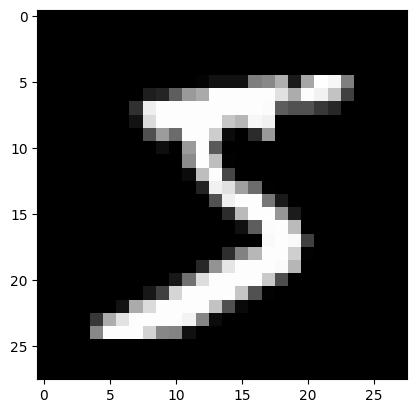

In [7]:
plt.imshow(train_set[0][0].squeeze(), cmap="gray")

## Part 1: Building the initial unet

We will now build initially an unconditioned unet, which does not take in the text-embedding. Our architecture uses 3x3 pooling with padding = 1 and a 2x2 MaxPool and ReLU activation. for the upsampling, we use 3x3 convolutions with padding 1 and 2x2 upsampling (interpolation) steps. the upsampling steps do not have learnable parameters. We have a variable number of convs_per_level convolutions before each pooling or upsampling step

This is adapted from the original paper introducing the unet (Ronneberger et al).

in the first step, we don't put in skip connections, etc (although if I understand it correctly, the skip connections are very much a defining feature of the unet, and what i build here is more of a VAE) we will look at all this stuff later. also we will ignore time embedding for now.


In [8]:
from typing import List


class UNet(nn.Module):

    def __init__(self, channels: List[int] = [32, 64, 128], convs_per_level=2,
                 kernel_size=3, pool_size=2, padding=1):
        super().__init__()
        
        full_channels = [1] + channels + channels[-2::-1]
        # [1, 8, 16, 32, 16, 8] 
        
        self.mid = len(full_channels) // 2

        self.encoder_convs = nn.ModuleList([
            # one ModuleList per resolution level (so this is a Module List of BLocks of N convs)
            # first conv changes channels: full_channels[i] -> full_channels[i+1]
            # remaining convs keep channels constant: full_channels[i+1] -> full_channels[i+1]
            # example with channels=[8,16,32], convs_per_level=2:
            #   level 0 (28x28): Conv(1->8),  Conv(8->8)
            #   level 1 (14x14): Conv(8->16), Conv(16->16)
            #   level 2 (7x7):   Conv(16->32), Conv(32->32)  <- bottleneck, no pool after
            nn.ModuleList([
                nn.Conv2d(full_channels[i] if j == 0 else full_channels[i+1],
                          full_channels[i+1], kernel_size, padding=padding)
                for j in range(convs_per_level)
            ])
            for i in range(self.mid)
        ])

        self.decoder_convs = nn.ModuleList([
            # one ModuleList per resolution level
            # first conv takes concatenated skip+upsampled: (full_channels[mid+i] + full_channels[mid-i-1]) -> full_channels[mid+i+1]
            # remaining convs keep channels constant: full_channels[mid+i+1] -> full_channels[mid+i+1]
            # example with channels=[8,16,32], convs_per_level=2:
            #   level 0 (7x7->14x14):  Conv(32+16->16), Conv(16->16)
            #   level 1 (14x14->28x28): Conv(16+8->8),  Conv(8->8)
            # then output_conv: Conv(8->1, kernel=1)
            nn.ModuleList([
                nn.Conv2d(
                    (full_channels[self.mid + i] + full_channels[self.mid - i - 1]) if j == 0
                    else full_channels[self.mid + i + 1],
                    full_channels[self.mid + i + 1],
                    kernel_size, padding=padding
                )
                for j in range(convs_per_level)
            ])
            for i in range(len(full_channels) - self.mid - 1)
        ])

        # final output conv: 8 -> 1, no activation
        self.output_conv = nn.Conv2d(full_channels[-1], 1, kernel_size=1)

        self.pool = nn.MaxPool2d(pool_size)
        self.upsample = nn.Upsample(scale_factor=pool_size)
        self.activation_fn = F.relu

    def forward(self, x):
        skips = []
        last_encoder = len(self.encoder_convs) - 1
        for i, conv_block in enumerate(self.encoder_convs):
            for conv in conv_block:
                x = self.activation_fn(conv(x))
            if i < last_encoder:
                skips.append(x)
                x = self.pool(x)

        for i, conv_block in enumerate(self.decoder_convs):
            x = self.upsample(x)
            x = torch.cat([x, skips.pop()], dim=1)
            for conv in conv_block:
                x = self.activation_fn(conv(x))

        return self.output_conv(x)  # no activation on final layer

### training the model


For speeding up, i use autocast and GradScaler, which, where it is possible, scales numbers to half precision (16 bit), which on gpus allows for significant improvements in speed. GradScaler and autocast deal with issues that can arise here when we just use .half().


In [9]:
def find_lr(model, train_loader, start_lr=1e-7, end_lr=1, num_iter=100):
    optimizer = torch.optim.Adam(model.parameters(), lr=start_lr)
    lr_finder = LRFinder(model, optimizer, F.mse_loss)
    lr_finder.range_test(train_loader, end_lr=end_lr, num_iter=num_iter)
    lr_finder.plot()
    lr_finder.reset()
    return lr_finder

we add gradient clipping here also

In [10]:
def train(model, train_loader, test_loader, epochs=100, lr=1e-2, plot_loss=True,
          early_stopping_patience=10, save_path='model.pkl'):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scaler = torch.amp.GradScaler('cuda')
    lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=3, factor=0.5, min_lr=1e-6)

    loss_fn = nn.MSELoss()
    train_losses, test_losses = [], []

    best_test_loss = float('inf')
    patience_counter = 0

    for epoch in tqdm(range(epochs), desc='Epochs'):
        model.train()
        epoch_train_loss = 0
        for x_noisy, noise in tqdm(train_loader, leave=False, desc='train'):
            x_noisy, noise = x_noisy.to(device), noise.to(device)
            with torch.amp.autocast('cuda'):
                noise_pred = model(x_noisy)
                loss = loss_fn(noise_pred, noise)
            epoch_train_loss += loss.item()
            optimizer.zero_grad()
            scaler.scale(loss).backward()
            
            # gradient clipping
            scaler.unscale_(optimizer)
            # Clip the gradients (max_norm=1.0 is a common default)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)


            scaler.step(optimizer)
            scaler.update()
        train_losses.append(epoch_train_loss / len(train_loader))

        model.eval()
        epoch_test_loss = 0
        with torch.no_grad():
            for x_noisy, noise in tqdm(test_loader, leave=False, desc='test'):
                x_noisy, noise = x_noisy.to(device), noise.to(device)
                with torch.amp.autocast('cuda'):
                    noise_pred = model(x_noisy)
                    epoch_test_loss += loss_fn(noise_pred, noise).item()
            test_loss = epoch_test_loss / len(test_loader)
            lr_scheduler.step(test_loss)
        test_losses.append(test_loss)

        print(
            f"Epoch {epoch} | train loss: {train_losses[-1]:.4f} | test loss: {test_losses[-1]:.4f}")

        # early stopping
        if test_losses[-1] < best_test_loss:
            best_test_loss = test_losses[-1]
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
        else:
            patience_counter += 1
            if patience_counter >= early_stopping_patience:
                print(f"Early stopping at epoch {epoch}")
                break

    # restore best model
    model.load_state_dict(torch.load(save_path))

    if plot_loss:
        plt.figure(figsize=(8, 4))
        plt.plot(train_losses, label='Train')
        plt.plot(test_losses, label='Test')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Loss curve')
        plt.legend()
        plt.tight_layout()
        plt.show()

    return train_losses, test_losses

### Generating an image


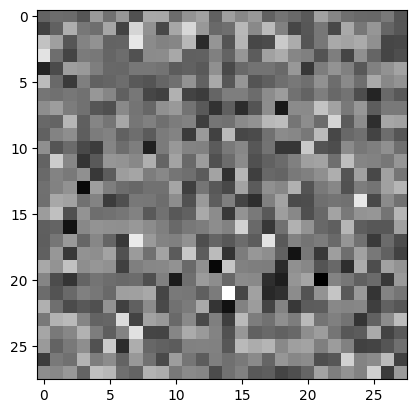

In [11]:
example_image = train_set[0][0].squeeze()


def noisy_image(n=1):
    """generates a batch of n noisy images. Output shape: (nx28x28)"""
    return torch.randn((n, 1, *example_image.shape))


plt.imshow(noisy_image().squeeze(), cmap="gray")
plt.show()

In [12]:
def generate_image(unet, scheduler, stochasticity=1.0, n_images=1, return_intermediates=False):
    intermediates = []
    unet.eval()

    x = noisy_image(n_images).to(device)
    if return_intermediates:
        intermediates.append(x.cpu())

    with torch.no_grad():
        for t in range(scheduler.T-1, 0, -1):
            z = noisy_image(n_images).to(device) if t > 1 else torch.zeros_like(x)
            alpha = scheduler.alpha(t)
            alpha_bar = scheduler.alpha_bar(t)
            # sigma_t is here for this simple case set to sqrt(beta), like in the original ho et al paper
            sigma_t = stochasticity*torch.sqrt(scheduler.beta(t))

            noise_pred = unet(x)
            x = 1/torch.sqrt(alpha) * (x - (1-alpha) /
                                    torch.sqrt(1-alpha_bar)*noise_pred) + sigma_t*z

            # print(t, alpha_bar.item(), (1-alpha_bar).item())

            if return_intermediates:
                intermediates.append(x.cpu())

    if return_intermediates:
        return x, intermediates

    return x

In [13]:
def plot_image(image):
    plt.imshow(image.cpu().detach().squeeze(), cmap="gray")
    plt.colorbar()

### changing stochasticity (i.e. DDPM vs DDIM)

we can change how much noise we add back into the image


In [14]:
def plot_stochasticities(model, scheduler, stochasticities=[0, 0.2, 0.4, 0.6, 0.8, 1.0], ncols=3):
    nrows = len(stochasticities) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*2, nrows*2))
    
    for ax, s in zip(axes.flat, stochasticities):
        image = generate_image(model, scheduler, stochasticity=s, n_images=1)
        ax.imshow(image.cpu().detach().squeeze(), cmap='gray')
        ax.set_title(f's={s}')
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

### Testing different channel numbers and convs_per_level

32,64,128, convs_per_level 1

  0%|          | 0/100 [00:00<?, ?it/s]

Stopping early, the loss has diverged
Learning rate search finished. See the graph with {finder_name}.plot()
LR suggestion: steepest gradient
Suggested LR: 2.85E-03


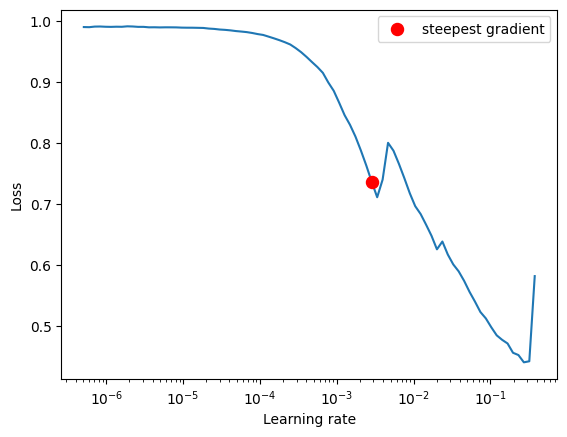

In [15]:
channels = [32, 64, 128]
model = UNet(channels,convs_per_level=1).to(device)
find_lr(model, train_loader)

Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

train:   0%|          | 0/186 [00:00<?, ?it/s]

test:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 0 | train loss: 0.1899 | test loss: 0.1054


train:   0%|          | 0/186 [00:00<?, ?it/s]

...

test:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 8 | train loss: 0.0494 | test loss: 0.0601


train:   0%|          | 0/186 [00:00<?, ?it/s]

test:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 9 | train loss: 0.0498 | test loss: 0.0475


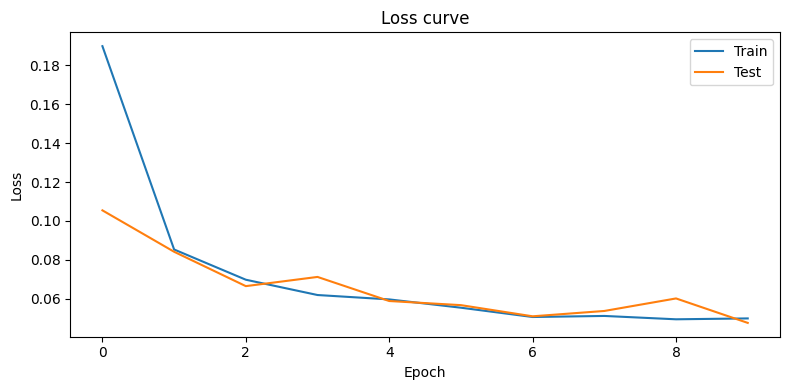

In [16]:
model = UNet(channels,convs_per_level=1).to(device)

lr = 1e-3

train(model, train_loader, test_loader,
      epochs=10, lr=lr, early_stopping_patience=15,
      save_path='model_unet_no_t_emb.pkl');

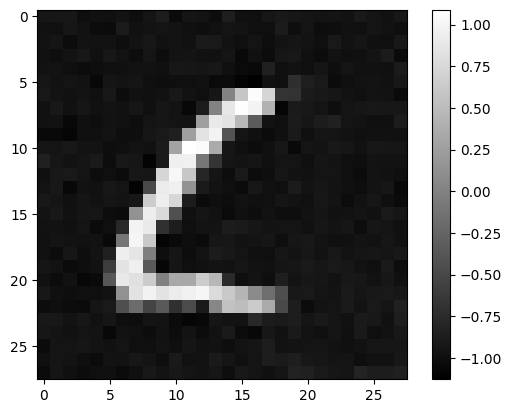

In [17]:
scheduler = NoiseScheduler(T=1000)

image, intermediates = generate_image(model, scheduler, stochasticity=1,
                                      n_images=1, return_intermediates=True)
plot_image(image)

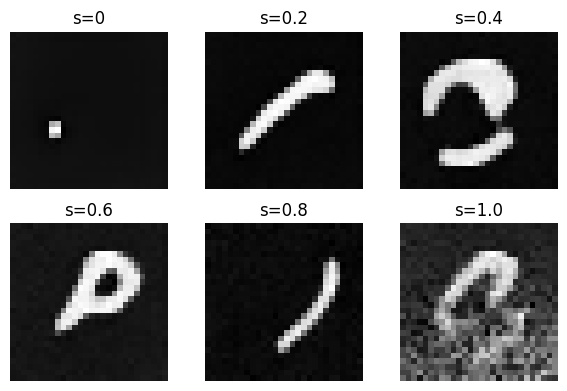

In [18]:
plot_stochasticities(model,scheduler)

doesn't look amazing

64,128,256

  0%|          | 0/100 [00:00<?, ?it/s]

Stopping early, the loss has diverged
Learning rate search finished. See the graph with {finder_name}.plot()
LR suggestion: steepest gradient
Suggested LR: 1.48E-03


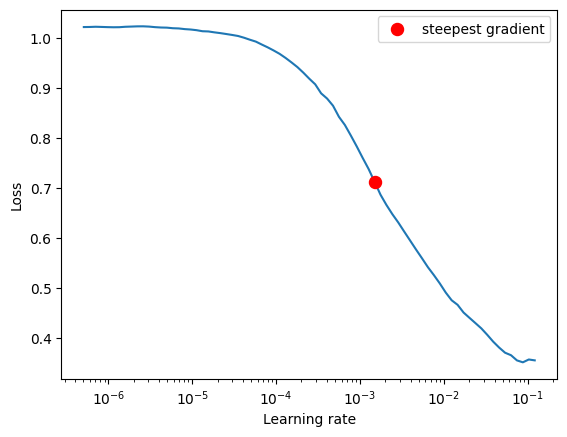

In [19]:
channels = [64, 128,256]
model = UNet(channels,convs_per_level=1).to(device)
find_lr(model, train_loader)

Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

train:   0%|          | 0/186 [00:00<?, ?it/s]

test:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 0 | train loss: 0.1760 | test loss: 0.0955


train:   0%|          | 0/186 [00:00<?, ?it/s]

...

test:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 8 | train loss: 0.0471 | test loss: 0.0469


train:   0%|          | 0/186 [00:00<?, ?it/s]

test:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 9 | train loss: 0.0469 | test loss: 0.0520


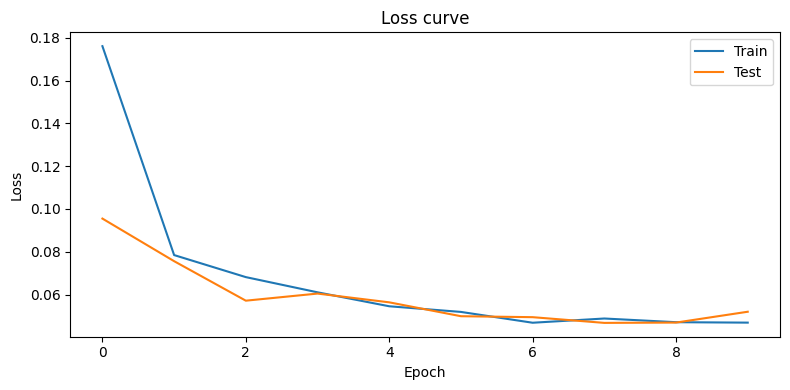

In [20]:
model = UNet(channels,convs_per_level=1).to(device)

lr = 1e-3

train(model, train_loader, test_loader,
      epochs=10, lr=lr, early_stopping_patience=15,
      save_path='model_unet_no_t_emb.pkl');

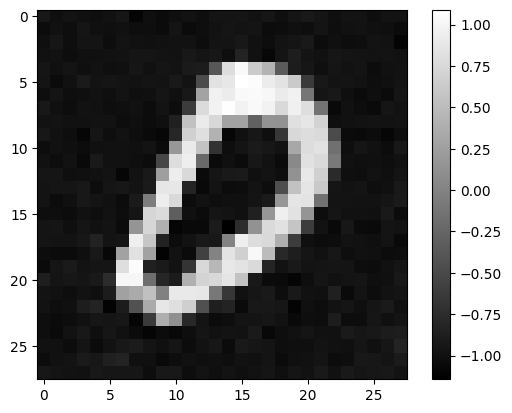

In [21]:
scheduler = NoiseScheduler(T=1000)

image, intermediates = generate_image(model, scheduler, stochasticity=1,
                                      n_images=1, return_intermediates=True)
plot_image(image)

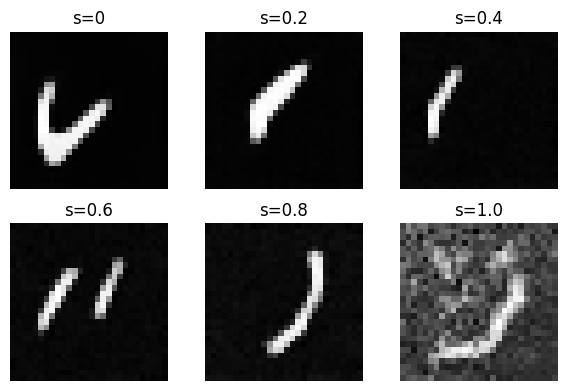

In [22]:
plot_stochasticities(model,scheduler)

doesn't look amazing either

128,256,512

  0%|          | 0/100 [00:00<?, ?it/s]

Stopping early, the loss has diverged
Learning rate search finished. See the graph with {finder_name}.plot()
LR suggestion: steepest gradient
Suggested LR: 4.75E-04


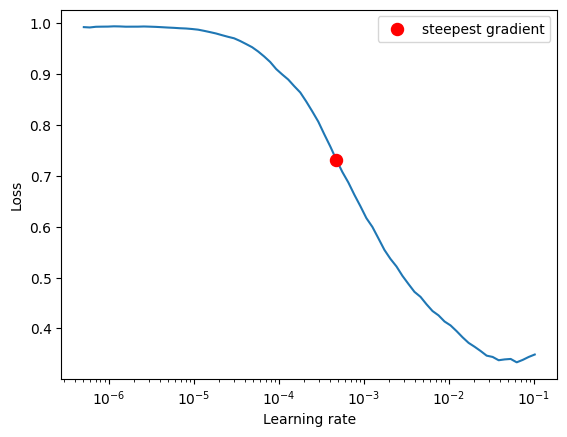

In [23]:
channels = [128,256,512]
model = UNet(channels,convs_per_level=1).to(device)
find_lr(model, train_loader)

Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

train:   0%|          | 0/186 [00:00<?, ?it/s]

test:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 0 | train loss: 0.1811 | test loss: 0.0778


train:   0%|          | 0/186 [00:00<?, ?it/s]

...

test:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 8 | train loss: 0.0430 | test loss: 0.0444


train:   0%|          | 0/186 [00:00<?, ?it/s]

test:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 9 | train loss: 0.0399 | test loss: 0.0405


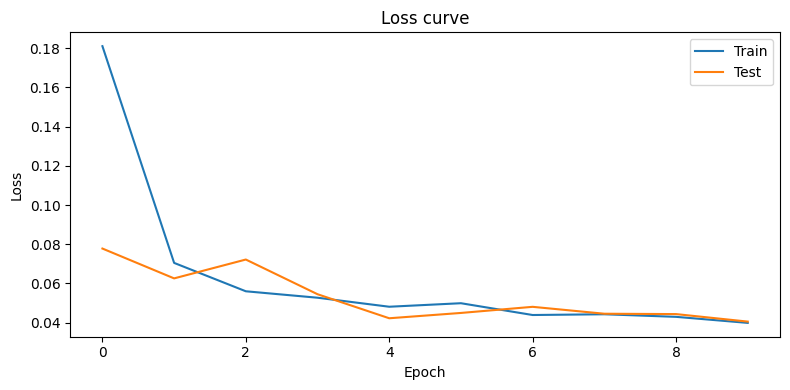

In [24]:
model = UNet(channels,convs_per_level=1).to(device)

lr = 3e-4

train(model, train_loader, test_loader,
      epochs=10, lr=lr, early_stopping_patience=15,
      save_path='model_unet_no_t_emb.pkl');

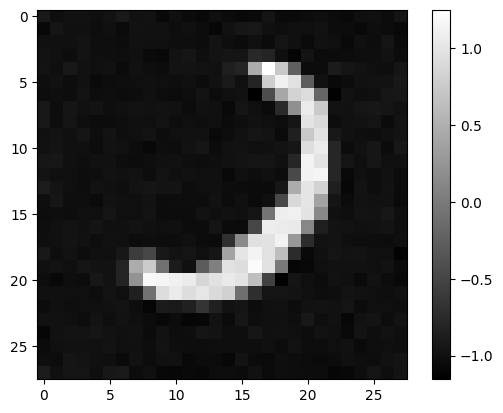

In [25]:
scheduler = NoiseScheduler(T=1000)

image, intermediates = generate_image(model, scheduler, stochasticity=1,
                                      n_images=1, return_intermediates=True)
plot_image(image)

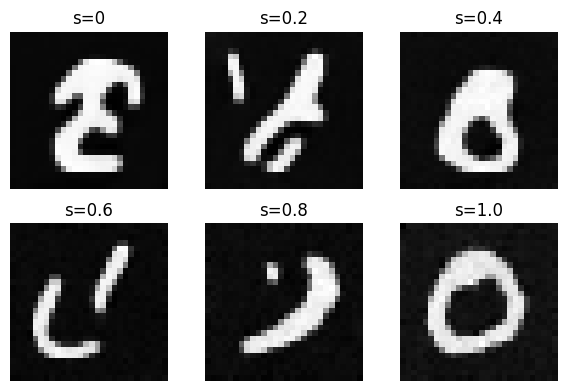

In [26]:
plot_stochasticities(model,scheduler)

this is what works so far. larger networks are simply better it seems

increasing convs_per_level to 2

  0%|          | 0/100 [00:00<?, ?it/s]

Stopping early, the loss has diverged
Learning rate search finished. See the graph with {finder_name}.plot()
LR suggestion: steepest gradient
Suggested LR: 3.94E-03


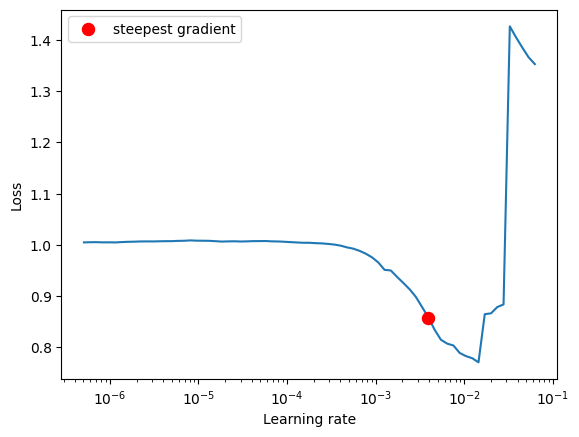

In [27]:
channels = [32,64,128]
model = UNet(channels,convs_per_level=2).to(device)
find_lr(model, train_loader)

Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

train:   0%|          | 0/186 [00:00<?, ?it/s]

test:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 0 | train loss: 0.1778 | test loss: 0.0865


train:   0%|          | 0/186 [00:00<?, ?it/s]

...

test:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 8 | train loss: 0.0443 | test loss: 0.0425


train:   0%|          | 0/186 [00:00<?, ?it/s]

test:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 9 | train loss: 0.0430 | test loss: 0.0476


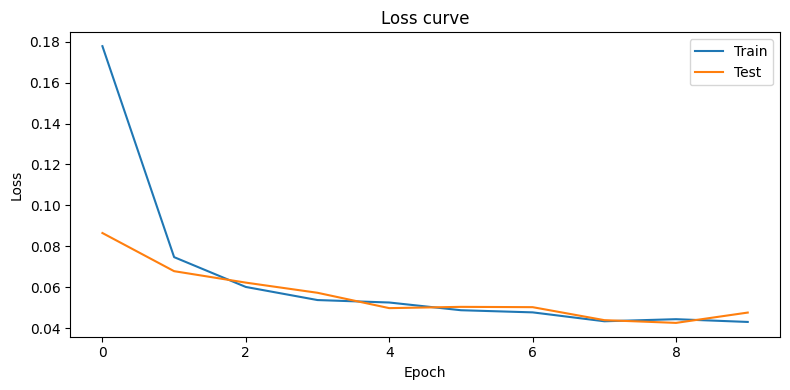

In [28]:
model = UNet(channels,convs_per_level=2).to(device)

lr = 2e-3

train(model, train_loader, test_loader,
      epochs=10, lr=lr, early_stopping_patience=15,
      save_path='model_unet_no_t_emb.pkl');

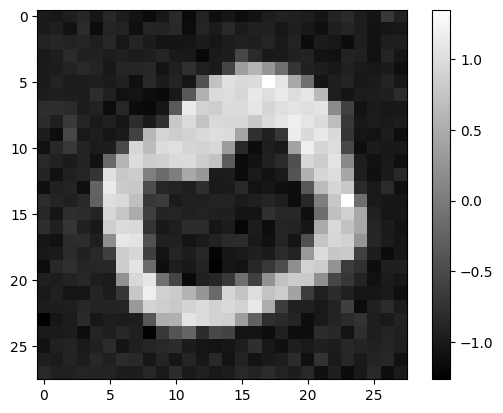

In [29]:
scheduler = NoiseScheduler(T=1000)

image, intermediates = generate_image(model, scheduler, stochasticity=1,
                                      n_images=1, return_intermediates=True)
plot_image(image)

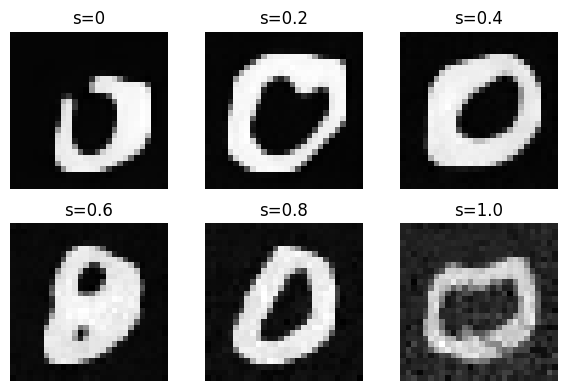

In [30]:
plot_stochasticities(model,scheduler)

still not great

  0%|          | 0/100 [00:00<?, ?it/s]

Learning rate search finished. See the graph with {finder_name}.plot()
LR suggestion: steepest gradient
Suggested LR: 6.43E-03


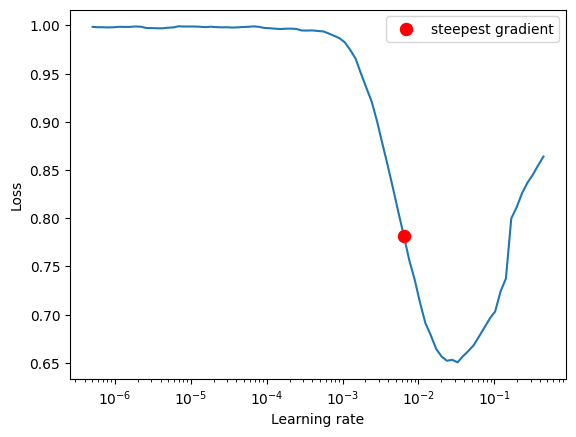

In [31]:
channels = [32, 64, 128]
model = UNet(channels,convs_per_level=3).to(device)
find_lr(model, train_loader)

Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

train:   0%|          | 0/186 [00:00<?, ?it/s]

test:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 0 | train loss: 6.4696 | test loss: 0.1041


train:   0%|          | 0/186 [00:00<?, ?it/s]

...

test:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 8 | train loss: 0.0607 | test loss: 0.0671


train:   0%|          | 0/186 [00:00<?, ?it/s]

test:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 9 | train loss: 0.0604 | test loss: 0.0572


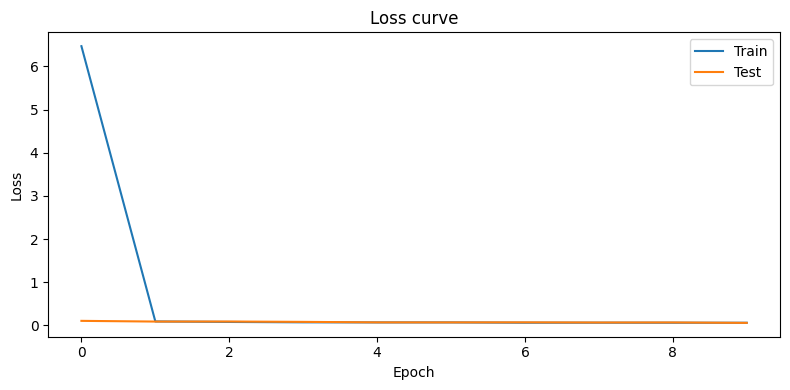

In [32]:
model = UNet(channels,convs_per_level=3).to(device)

lr = 4e-3

train(model, train_loader, test_loader,
      epochs=10, lr=lr, early_stopping_patience=15,
      save_path='model_unet_no_t_emb.pkl');

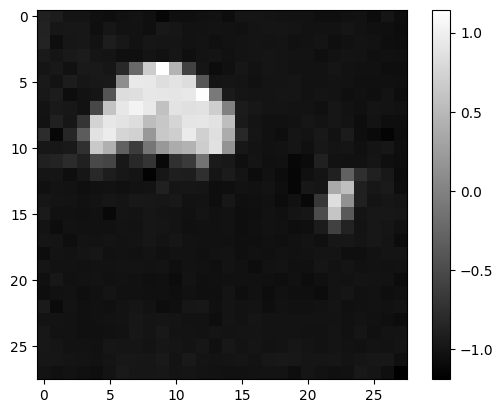

In [33]:
scheduler = NoiseScheduler(T=1000)

image, intermediates = generate_image(model, scheduler, stochasticity=1,
                                      n_images=1, return_intermediates=True)
plot_image(image)

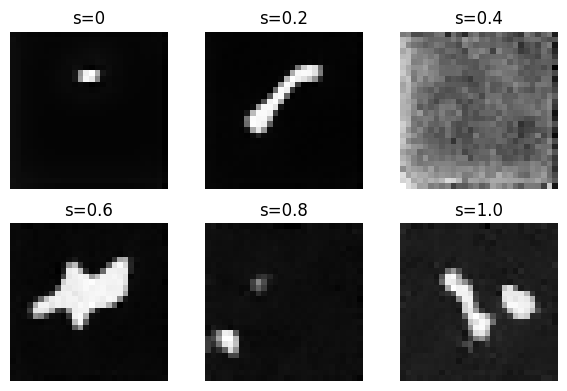

In [34]:
plot_stochasticities(model,scheduler)

this doesn't give us immediate progress, but that could also be due to the training times.

What about a combination of larger channel sizes and 2 convs per layer?

64,128,256, 2 convs

  0%|          | 0/100 [00:00<?, ?it/s]

Stopping early, the loss has diverged
Learning rate search finished. See the graph with {finder_name}.plot()
LR suggestion: steepest gradient
Suggested LR: 2.36E-02


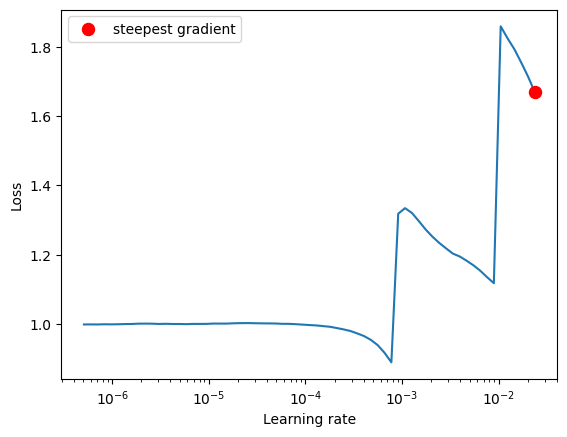

In [35]:
channels = [64, 128, 256]
model = UNet(channels,convs_per_level=2).to(device)
find_lr(model, train_loader)

Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

train:   0%|          | 0/186 [00:00<?, ?it/s]

test:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 0 | train loss: 0.3316 | test loss: 0.1220


train:   0%|          | 0/186 [00:00<?, ?it/s]

...

test:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 8 | train loss: 0.0413 | test loss: 0.0454


train:   0%|          | 0/186 [00:00<?, ?it/s]

test:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 9 | train loss: 0.0401 | test loss: 0.0409


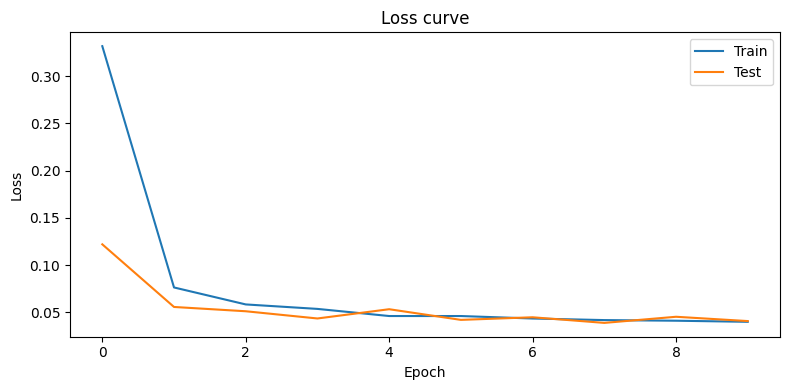

In [36]:
model = UNet(channels,convs_per_level=2).to(device)

lr = 1e-3

train(model, train_loader, test_loader,
      epochs=10, lr=lr, early_stopping_patience=15,
      save_path='model_unet_no_t_emb.pkl');

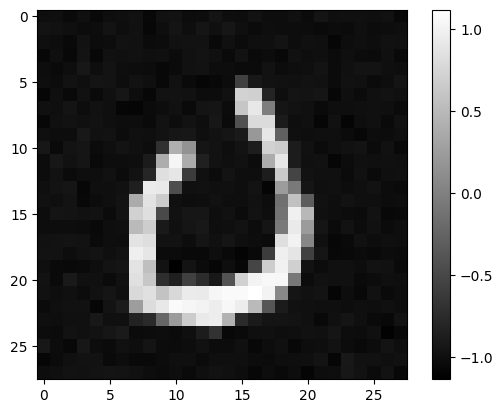

In [37]:
scheduler = NoiseScheduler(T=1000)

image, intermediates = generate_image(model, scheduler, stochasticity=1,
                                      n_images=1, return_intermediates=True)
plot_image(image)

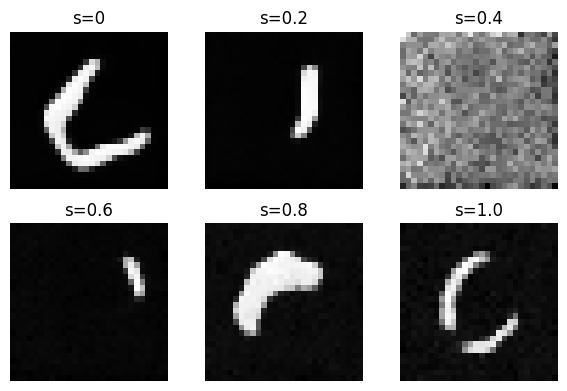

In [38]:
plot_stochasticities(model,scheduler)

this also seems to work kind of well

### Intermediary conclusion

Larger networks work better, which isn't a surprise really. conv_per_layer 1 with 128,256,512 seemed to work best. That the convs_per_layer increases didn't really help could be due to not long enough training times. since we also do this in the real architecture, I will now train for a longer time a model with 128,256,512 and conv_per_layer 1 and one with 64,128,256 channels and 2 conv_per_layers.

In [39]:
model_names = ["C0_128_convs_1","C0_64_convs_2"]
training_losses,testing_losses = [],[]

Epochs:   0%|          | 0/200 [00:00<?, ?it/s]

train:   0%|          | 0/186 [00:00<?, ?it/s]

test:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 0 | train loss: 0.1561 | test loss: 0.0789


train:   0%|          | 0/186 [00:00<?, ?it/s]

...

test:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 61 | train loss: 0.0313 | test loss: 0.0293


train:   0%|          | 0/186 [00:00<?, ?it/s]

test:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 62 | train loss: 0.0320 | test loss: 0.0325
Early stopping at epoch 62


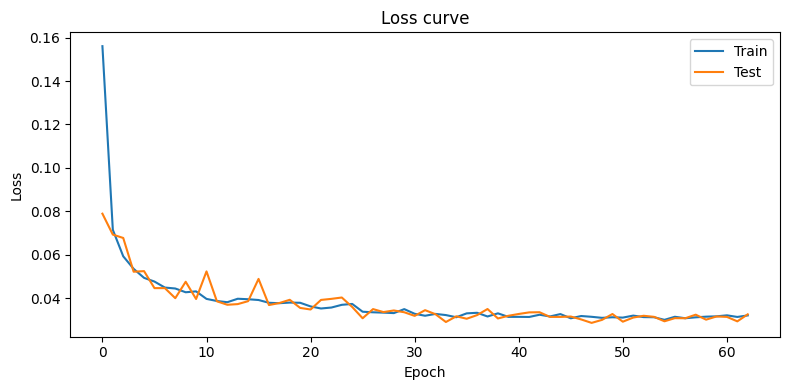

In [40]:
channels = [128,256,512]
model = UNet(channels,convs_per_level=1).to(device)

lr = 3e-4

trainloss,testloss = train(model, train_loader, test_loader,
      epochs=200, lr=lr, early_stopping_patience=15,
      save_path='model_unet_no_t_emb_C0_128_convs_1.pkl')

training_losses.append(trainloss)
testing_losses.append(testloss)

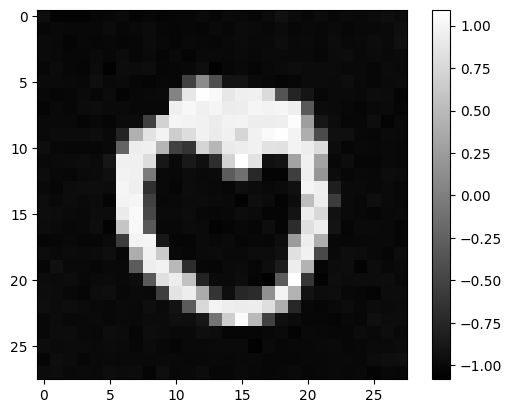

In [41]:
scheduler = NoiseScheduler(T=1000)

image, intermediates = generate_image(model, scheduler, stochasticity=1,
                                      n_images=1, return_intermediates=True)
plot_image(image)

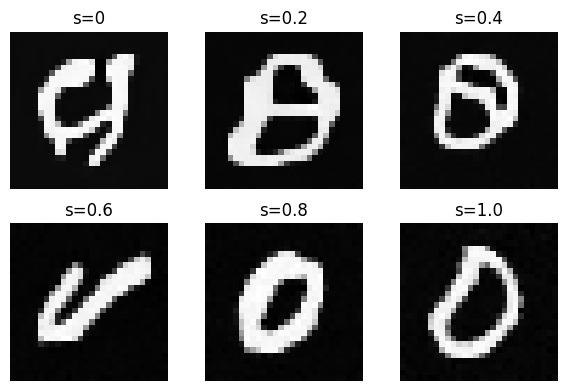

In [42]:
plot_stochasticities(model,scheduler)

Epochs:   0%|          | 0/200 [00:00<?, ?it/s]

train:   0%|          | 0/186 [00:00<?, ?it/s]

test:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 0 | train loss: 0.1821 | test loss: 0.1014


train:   0%|          | 0/186 [00:00<?, ?it/s]

...

test:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 80 | train loss: 0.0290 | test loss: 0.0283


train:   0%|          | 0/186 [00:00<?, ?it/s]

test:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 81 | train loss: 0.0288 | test loss: 0.0315
Early stopping at epoch 81


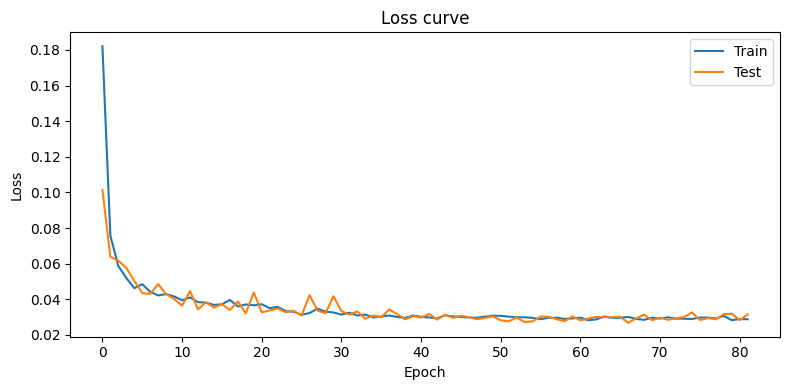

In [43]:
channels = [64,128,256]
model = UNet(channels,convs_per_level=2).to(device)

lr = 1e-3

trainloss,testloss = train(model, train_loader, test_loader,
      epochs=200, lr=lr, early_stopping_patience=15,
      save_path='model_unet_no_t_emb_C0_64_convs_2.pkl')

training_losses.append(trainloss)
testing_losses.append(testloss)

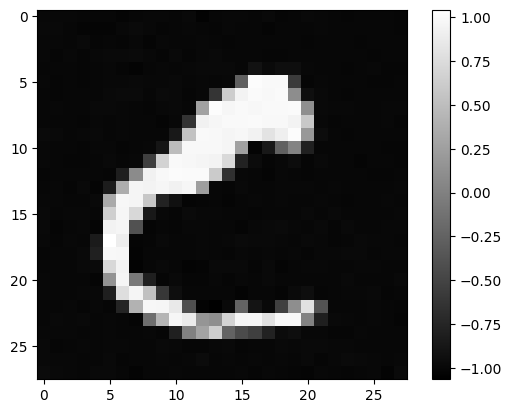

In [44]:
scheduler = NoiseScheduler(T=1000)

image, intermediates = generate_image(model, scheduler, stochasticity=1,
                                      n_images=1, return_intermediates=True)
plot_image(image)

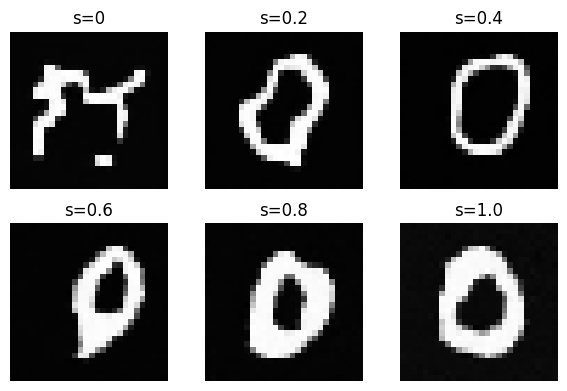

In [45]:
plot_stochasticities(model,scheduler)

loss wise does this second model slightly outperform the first one

### implementing the t embedding

TODO for tomorrow

then, send in


Steps:

time embedding

use cosine based variance schedule (nochol & dhariwal)

conditioning on input numbers
